# Динамика по месяцам: продажи, возвраты, денежный поток

Дополнение к главе 5: помесячные графики для наглядности динамики продаж (5.2), возвратов (5.3) и денежного потока (5.4).

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE = Path("..").resolve()
DATA = BASE / "Данные" / "Итоговые таблицы"
IMG_DIR = Path("img")
IMG_DIR.mkdir(exist_ok=True)

sales_by_counterparties = pd.read_parquet(DATA / "sales_by_counterparties.parquet")
bank_statement_transactions = pd.read_parquet(DATA / "bank_statement_transactions.parquet")

formatter = mticker.FuncFormatter(lambda value, _: f"{value:,.0f}".replace(",", " "))

start_date = "2025-06-01"
end_date = "2026-06-30"

## 5.2 — Продажи по месяцам

2025-06-01    2274957.00
2025-07-01    4232569.00
2025-08-01    4120009.00
2025-09-01    5299088.00
2025-10-01    6999511.70
2025-11-01    5543321.72
2025-12-01    4534850.52
2026-01-01    2041419.00
2026-02-01    4701630.00
2026-03-01    5245108.00
2026-04-01    3566490.00
2026-05-01    2084205.00
2026-06-01    1607000.00
Freq: MS, Name: amount, dtype: float64

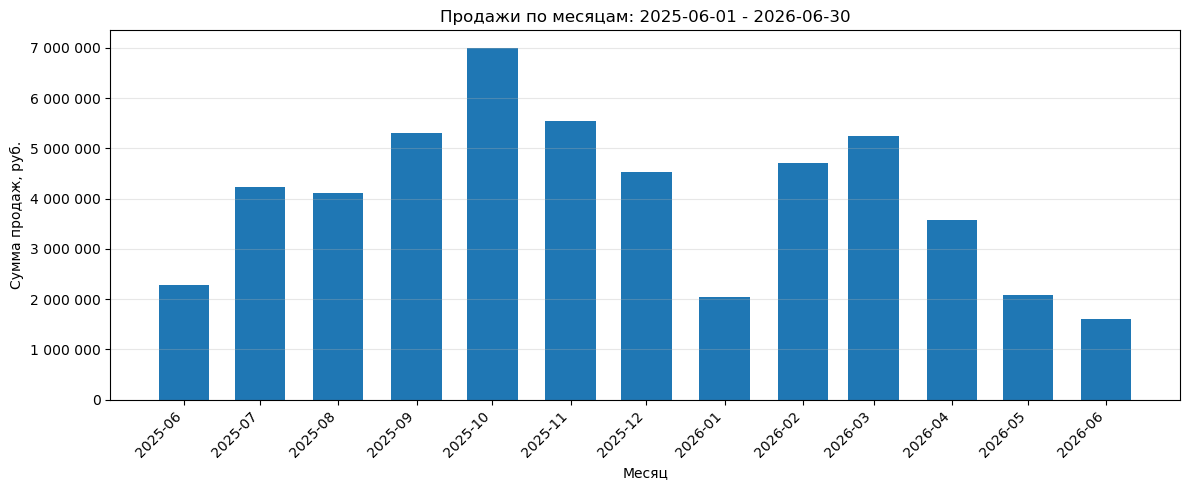

In [2]:
sales_period = sales_by_counterparties[
    sales_by_counterparties["sale_date"].between(start_date, end_date)
    & sales_by_counterparties["sales_doc_type"].eq("Реализация")
].copy()
sales_period["month"] = sales_period["sale_date"].dt.to_period("M").dt.to_timestamp()

monthly_sales = (
    sales_period.groupby("month")["amount"]
    .sum()
    .reindex(pd.period_range(start_date, end_date, freq="M").to_timestamp(), fill_value=0)
)

display(monthly_sales)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_sales.index, monthly_sales.values, width=20, color="#1f77b4")
ax.set_title(f"Продажи по месяцам: {start_date} - {end_date}")
ax.set_xlabel("Месяц")
ax.set_ylabel("Сумма продаж, руб.")
ax.yaxis.set_major_formatter(formatter)
ax.set_xticks(monthly_sales.index)
ax.set_xticklabels([d.strftime("%Y-%m") for d in monthly_sales.index], rotation=45, ha="right")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(IMG_DIR / "monthly_sales.png", dpi=150)
plt.show()

## 5.3 — Возвраты по месяцам

,"возврат, руб.",% от продаж
2025-06-01,633261.00,27.8
2025-07-01,246600.00,5.8
2025-08-01,715560.00,17.4
2025-09-01,625840.00,11.8
2025-10-01,221333.23,3.2
2025-11-01,298600.07,5.4
2025-12-01,447940.82,9.9
2026-01-01,542489.05,26.6
2026-02-01,412150.39,8.8
2026-03-01,1492042.82,28.4


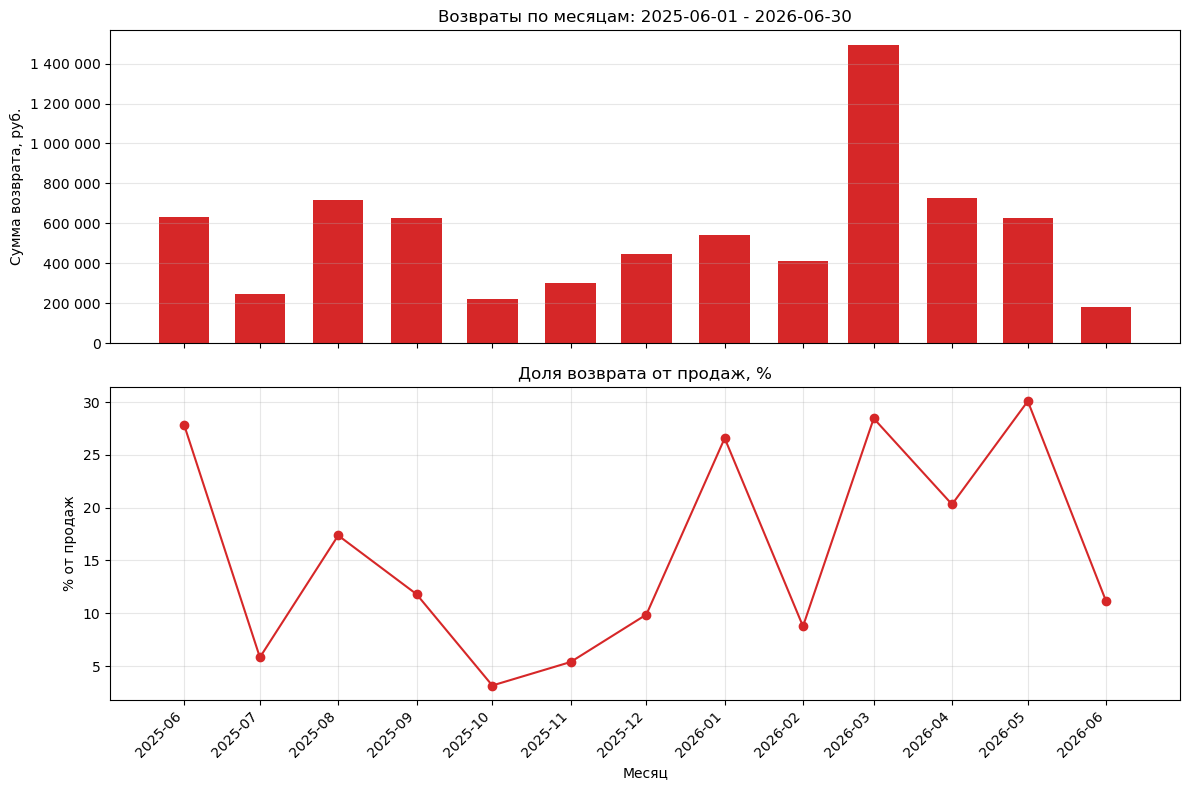

In [3]:
returns_period = sales_by_counterparties[
    sales_by_counterparties["sale_date"].between(start_date, end_date)
    & sales_by_counterparties["sales_doc_type"].eq("Корректировка реализации")
].copy()
returns_period["month"] = returns_period["sale_date"].dt.to_period("M").dt.to_timestamp()
returns_period["возврат"] = -returns_period["amount"]

monthly_returns = (
    returns_period.groupby("month")["возврат"]
    .sum()
    .reindex(pd.period_range(start_date, end_date, freq="M").to_timestamp(), fill_value=0)
)
monthly_return_rate = (monthly_returns / monthly_sales.replace(0, pd.NA) * 100).fillna(0)

display(pd.DataFrame({"возврат, руб.": monthly_returns, "% от продаж": monthly_return_rate.round(1)}))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.bar(monthly_returns.index, monthly_returns.values, width=20, color="#d62728")
ax1.set_title(f"Возвраты по месяцам: {start_date} - {end_date}")
ax1.set_ylabel("Сумма возврата, руб.")
ax1.yaxis.set_major_formatter(formatter)
ax1.grid(True, alpha=0.3, axis="y")

ax2.plot(monthly_return_rate.index, monthly_return_rate.values, marker="o", color="#d62728")
ax2.set_title("Доля возврата от продаж, %")
ax2.set_xlabel("Месяц")
ax2.set_ylabel("% от продаж")
ax2.set_xticks(monthly_returns.index)
ax2.set_xticklabels([d.strftime("%Y-%m") for d in monthly_returns.index], rotation=45, ha="right")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "monthly_returns.png", dpi=150)
plt.show()

## 5.4 — Денежный поток по месяцам

,приток,отток,чистый поток
2025-06-01,1145115.02,998547.04,146567.98
2025-07-01,1874679.72,1962956.59,-88276.87
2025-08-01,3891754.41,3744325.61,147428.80
2025-09-01,3602062.26,3863052.42,-260990.16
2025-10-01,5768109.82,5615202.61,152907.21
2025-11-01,5661947.73,5383176.61,278771.12
2025-12-01,5146962.60,5322154.48,-175191.88
2026-01-01,2659441.20,2514183.15,145258.05
2026-02-01,3147109.31,3497309.72,-350200.41
2026-03-01,4492541.43,4268021.74,224519.69


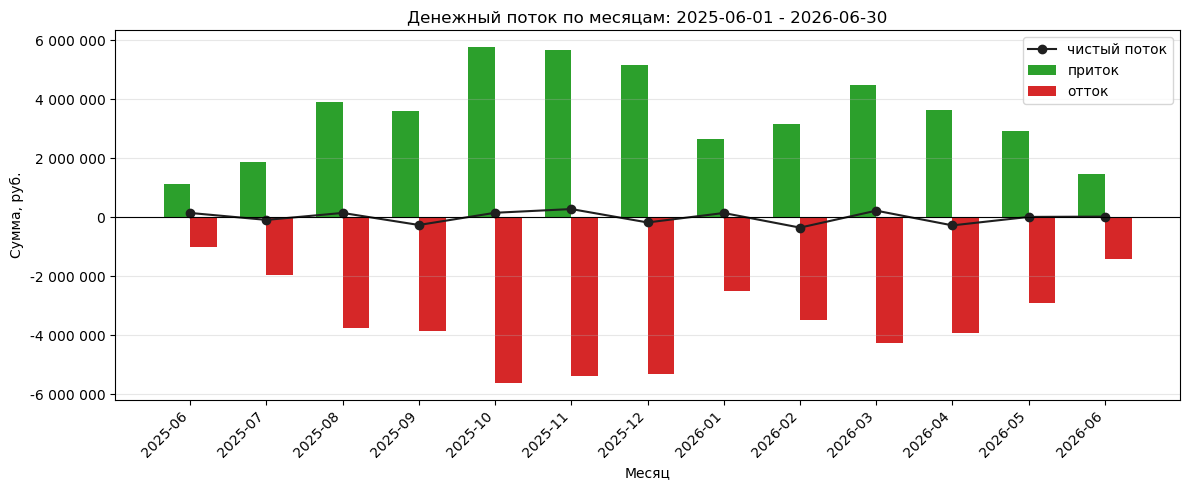

In [4]:
bank_period = bank_statement_transactions[
    bank_statement_transactions["operation_date"].between(start_date, end_date)
].copy()
bank_period["month"] = bank_period["operation_date"].dt.to_period("M").dt.to_timestamp()

monthly_cf = (
    bank_period.groupby("month")
    .agg(приток=("credit", "sum"), отток=("debit", "sum"))
    .reindex(pd.period_range(start_date, end_date, freq="M").to_timestamp(), fill_value=0)
)
monthly_cf["чистый поток"] = monthly_cf["приток"] - monthly_cf["отток"]

display(monthly_cf)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(monthly_cf.index))
width = 0.35
ax.bar([i - width / 2 for i in x], monthly_cf["приток"], width=width, label="приток", color="#2ca02c")
ax.bar([i + width / 2 for i in x], -monthly_cf["отток"], width=width, label="отток", color="#d62728")
ax.plot(x, monthly_cf["чистый поток"], marker="o", color="#1f1f1f", label="чистый поток")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"Денежный поток по месяцам: {start_date} - {end_date}")
ax.set_xlabel("Месяц")
ax.set_ylabel("Сумма, руб.")
ax.yaxis.set_major_formatter(formatter)
ax.set_xticks(list(x))
ax.set_xticklabels([d.strftime("%Y-%m") for d in monthly_cf.index], rotation=45, ha="right")
ax.grid(True, alpha=0.3, axis="y")
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / "monthly_cashflow.png", dpi=150)
plt.show()